                 AML INDIVIDUAL TASK

DATASET SHAPE
(4269, 13)

FIRST FIVE ROWS
   loan_id  no_of_dependents      education self_employed  income_annum  \
0        1                 2       Graduate            No       9600000   
1        2                 0   Not Graduate           Yes       4100000   
2        3                 3       Graduate            No       9100000   
3        4                 3       Graduate            No       8200000   
4        5                 5   Not Graduate           Yes       9800000   

   loan_amount  loan_term  cibil_score  residential_assets_value  \
0     29900000         12          778                   2400000   
1     12200000          8          417                   2700000   
2     29700000         20          506                   7100000   
3     30700000          8          467                  18200000   
4     24200000         20          382                  12400000   

   commercial_assets_value  luxury_assets_value  bank_asset_

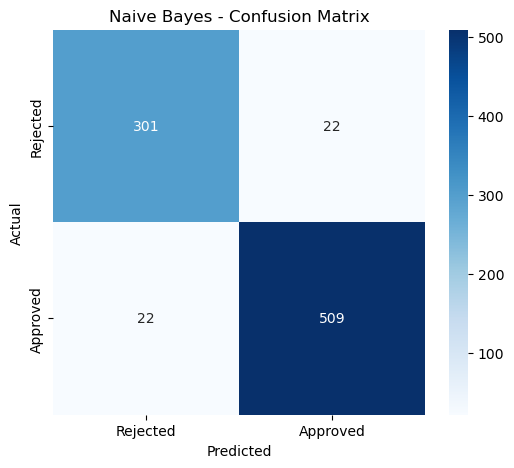

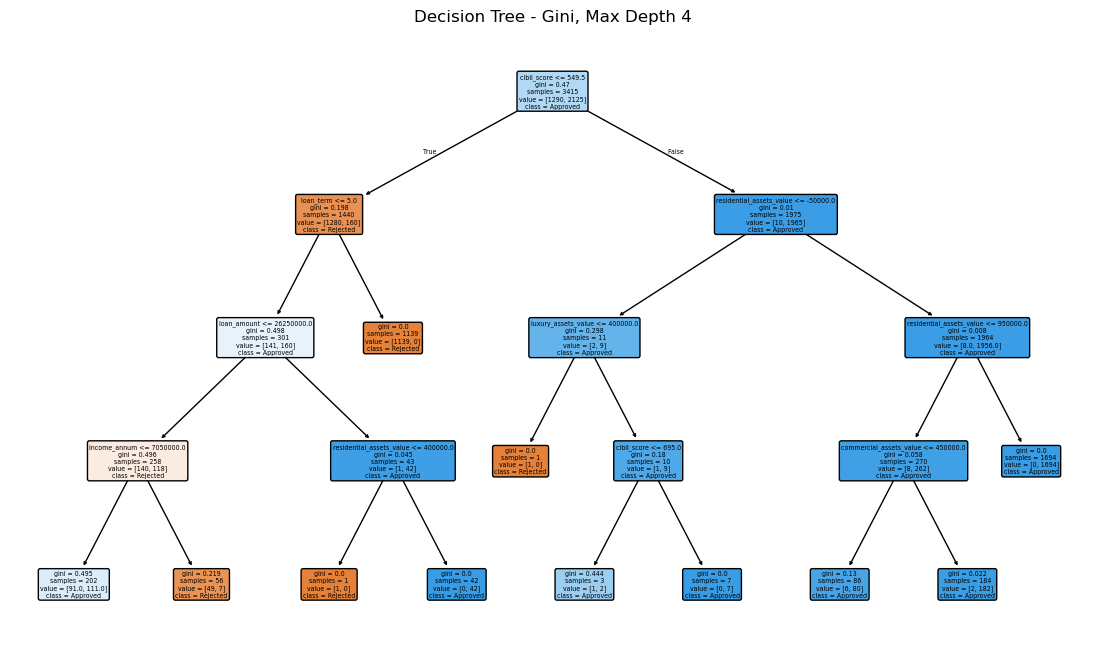


MODEL COMPARISON
             Algorithm  Accuracy  Precision    Recall  F1 Score
0          Naive Bayes  0.948478   0.958569  0.958569  0.958569
1        Decision Tree  0.970726   0.955036  1.000000  0.977001
2  Logistic Regression  0.913349   0.920810  0.941620  0.931099


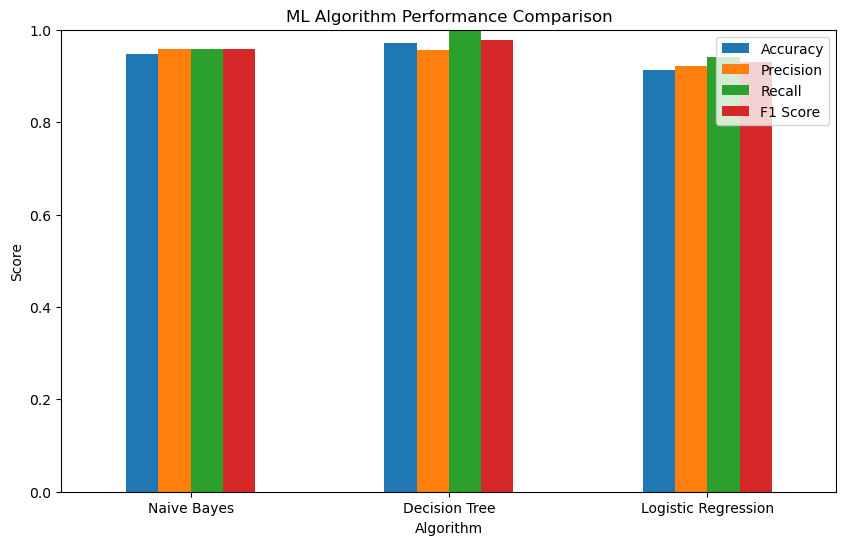


BEST PERFORMING ALGORITHM
Decision Tree
Accuracy: 0.9707259953161592


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("=" * 60)
print("                 AML INDIVIDUAL TASK")
print("=" * 60)

df = pd.read_csv("loan_approval_dataset1.csv")

df.columns = df.columns.str.strip()

print("\nDATASET SHAPE")
print(df.shape)

print("\nFIRST FIVE ROWS")
print(df.head())

df["education"] = df["education"].str.strip()
df["self_employed"] = df["self_employed"].str.strip()
df["loan_status"] = df["loan_status"].str.strip()

df["education"] = df["education"].map({
    "Graduate": 1,
    "Not Graduate": 0
})

df["self_employed"] = df["self_employed"].map({
    "Yes": 1,
    "No": 0
})

df["loan_status"] = df["loan_status"].map({
    "Approved": 1,
    "Rejected": 0
})

X = df.drop(["loan_id", "loan_status"], axis=1)
y = df["loan_status"]

print("\nTARGET NAME")
print("loan_status")

print("\nFEATURE NAMES")
print(list(X.columns))

print("\nTARGET CLASSES")
print(["Rejected", "Approved"])

X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

nb_model = GaussianNB()

dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

lr_model = LogisticRegression(max_iter=1000)

nb_model.fit(X_train_scaled, y_train)
dt_model.fit(X_train, y_train)
lr_model.fit(X_train_scaled, y_train)

nb_pred = nb_model.predict(X_test_scaled)
dt_pred = dt_model.predict(X_test)
lr_pred = lr_model.predict(X_test_scaled)

print("\nNAIVE BAYES CLASSIFICATION REPORT")
print(classification_report(
    y_test,
    nb_pred,
    target_names=["Rejected", "Approved"]
))

print("\nDECISION TREE CLASSIFICATION REPORT")
print(classification_report(
    y_test,
    dt_pred,
    target_names=["Rejected", "Approved"]
))

print("\nLOGISTIC REGRESSION CLASSIFICATION REPORT")
print(classification_report(
    y_test,
    lr_pred,
    target_names=["Rejected", "Approved"]
))

cm_nb = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rejected", "Approved"],
    yticklabels=["Rejected", "Approved"]
)

plt.title("Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(14, 8))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["Rejected", "Approved"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree - Gini, Max Depth 4")
plt.show()

results = []

for name, pred in [
    ("Naive Bayes", nb_pred),
    ("Decision Tree", dt_pred),
    ("Logistic Regression", lr_pred)
]:

    results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Algorithm",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

print("\nMODEL COMPARISON")
print(results_df)

results_df.set_index("Algorithm").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("ML Algorithm Performance Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

best_model = results_df.loc[
    results_df["Accuracy"].idxmax()
]

print("\nBEST PERFORMING ALGORITHM")
print(best_model["Algorithm"])
print("Accuracy:", best_model["Accuracy"])